# Phase 6 — LSTM Model
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Goal:** Train a 2-layer LSTM network on sequences of economic indicators (1990–2018) and forecast GDP per capita for the test period (2020–2024).

**Architecture:**
- Input: 5-year sliding window × 24 features per country
- Layer 1: LSTM(128) with return_sequences=True + Dropout(0.2)
- Layer 2: LSTM(64) + Dropout(0.2)
- Output: Dense(1) — next-year GDP per capita

**Metrics:** MAE, RMSE, MAPE, MASE, Directional Accuracy (DA)

In [16]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

OUTPUT = r"..\output"
TRAIN_END  = 2015
VAL_START  = 2016
VAL_END    = 2018
TEST_START = 2019
TEST_END   = 2024

pd.set_option("display.float_format", "{:.4f}".format)
print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)

TensorFlow : 2.18.0
Keras      : 3.6.0


## 1. Load & Prepare Data

In [17]:
# model_training_dataset.csv — 14 columns, zero leakage
# world_gdp_growth and pct_countries_contracting already present (computed in Phase 2)
df = pd.read_csv(os.path.join(OUTPUT, "model_training_dataset.csv"))
df = df.sort_values(["country_code", "year"]).reset_index(drop=True)
df = df.dropna(subset=["gdp_per_capita"])

# Encode country as integer (LSTM needs numeric inputs)
le = LabelEncoder()
df["country_encoded"] = le.fit_transform(df["country_code"])

# Target: next year GDP per capita (shift -1 within each country)
df["gdp_next_year"] = df.groupby("country_code")["gdp_per_capita"].transform(
    lambda x: x.shift(-1)
)

print("Shape   :", df.shape)
print("Years   :", df["year"].min(), "-", df["year"].max())
print("Countries:", df["country_code"].nunique())
print("Columns :", df.columns.tolist())

Shape   : (7240, 16)
Years   : 1990 - 2024
Countries: 212
Columns : ['country_code', 'year', 'gdp_per_capita', 'gdp_lag_1', 'gdp_lag_2', 'gdp_growth_rate', 'growth_lag_1', 'gdp_rolling_mean_3yr', 'inflation_hcpi', 'employment_rate', 'dependency_ratio', 'is_shock', 'world_gdp_growth', 'pct_countries_contracting', 'country_encoded', 'gdp_next_year']


## 2. Feature Selection & Dataset Construction

In [18]:
# ── FEATURE_COLS: same 14 as Phase 4 XGBoost — consistent, leak-free ────────
# Removed vs original: gdp_lag_3, growth_lag_2, all 5yr/std rolling,
#   interest_rate, population, world_gdp_growth_lag1
FEATURE_COLS = [
    "country_encoded",           # country identity
    "year",                      # time trend
    "gdp_per_capita",            # current GDP level
    "gdp_lag_1",                 # last year GDP
    "gdp_lag_2",                 # two years ago GDP
    "gdp_growth_rate",           # current growth rate
    "growth_lag_1",              # momentum
    "gdp_rolling_mean_3yr",      # 3-year rolling trend
    "inflation_hcpi",            # monetary pressure
    "employment_rate",           # labour market
    "dependency_ratio",          # demographic drag
    "is_shock",                  # binary shock flag
    "world_gdp_growth",          # global macro
    "pct_countries_contracting", # global contagion
]
TARGET  = "gdp_next_year"
SEQ_LEN = 5   # 5-year look-back window

needed   = list(dict.fromkeys(FEATURE_COLS + [TARGET, "country_code", "year"]))
model_df = df[needed].dropna(subset=[TARGET, "gdp_lag_1", "gdp_growth_rate"]).copy()
for col in FEATURE_COLS:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print(f"Modelling dataset : {model_df.shape}")
print(f"Features          : {len(FEATURE_COLS)}")
print(f"Sequence length   : {SEQ_LEN} years")
print(f"Missing in features: {model_df[FEATURE_COLS].isnull().sum().sum()}")

Modelling dataset : (6816, 16)
Features          : 14
Sequence length   : 5 years
Missing in features: 0


## 3. Scale Features
StandardScaler fitted on training rows only (1990–2018) and applied to all rows to avoid data leakage.

In [19]:
train_mask = model_df["year"] <= TRAIN_END
val_mask   = (model_df["year"] >= VAL_START) & (model_df["year"] <= VAL_END)
test_mask  = model_df["year"] >= TEST_START

scaler = StandardScaler()
scaler.fit(model_df.loc[train_mask, FEATURE_COLS])

model_df_scaled = model_df.copy()
model_df_scaled[FEATURE_COLS] = scaler.transform(model_df[FEATURE_COLS])

# Preserve unscaled year for train/test split in build_sequences
model_df_scaled["orig_year"] = model_df["year"].values

train_n = train_mask.sum()
val_n   = val_mask.sum()
test_n  = test_mask.sum()
print(f"Scaler fitted on {train_n} training rows (year <= {TRAIN_END})")
print(f"Training rows  : {train_n}")
print(f"Validation rows: {val_n}")
print(f"Test rows      : {test_n}")

Scaler fitted on 5133 training rows (year <= 2015)
Training rows  : 5133
Validation rows: 636
Test rows      : 1047


## 4. Build Sliding-Window Sequences
For each country, create overlapping 5-year sequences:
- **X**: features over 5 consecutive years → shape `(seq_len, n_features)`
- **y**: GDP in the following year (next-year target)
- **Train**: sequences whose anchor year ≤ 2018 (predicting up to 2019)
- **Test**: anchor year 2019–2023 (predicting 2020–2024)

In [20]:
def build_sequences(mdf, feature_cols, target_col, seq_len, train_end, val_start, val_end, test_end):
    """Build per-country sliding-window sequences. Returns train/val/test arrays + test metadata."""
    X_tr, y_tr = [], []
    X_va, y_va = [], []
    X_te, y_te = [], []
    val_meta = []
    test_meta = []   # (country_code, anchor_year) for each test sequence

    for country, grp in mdf.groupby("country_code"):
        grp     = grp.sort_values("orig_year").reset_index(drop=True)
        feats   = grp[feature_cols].values   # (T, F) — scaled
        targets = grp[target_col].values     # (T,)
        years   = grp["orig_year"].values    # (T,) — original unscaled years

        for i in range(seq_len - 1, len(grp)):
            seq_X    = feats[i - seq_len + 1 : i + 1]   # (seq_len, F)
            seq_y    = targets[i]
            seq_year = int(years[i])

            if seq_year <= train_end:
                X_tr.append(seq_X)
                y_tr.append(seq_y)
            elif val_start <= seq_year <= val_end:
                X_va.append(seq_X)
                y_va.append(seq_y)
                val_meta.append({"country_code": country, "year": seq_year})
            elif seq_year <= test_end - 1:   # anchor t -> predict t+1 (max t+1 = TEST_END)
                X_te.append(seq_X)
                y_te.append(seq_y)
                test_meta.append({"country_code": country, "year": seq_year})

    return (
        np.array(X_tr, dtype=np.float32), np.array(y_tr, dtype=np.float32),
        np.array(X_va, dtype=np.float32), np.array(y_va, dtype=np.float32),
        np.array(X_te, dtype=np.float32), np.array(y_te, dtype=np.float32),
        pd.DataFrame(val_meta).reset_index(drop=True),
        pd.DataFrame(test_meta).reset_index(drop=True),
    )

X_train, y_train, X_val, y_val, X_test, y_test, val_meta, test_meta = build_sequences(
    model_df_scaled, FEATURE_COLS, TARGET, SEQ_LEN,
    train_end=TRAIN_END, val_start=VAL_START, val_end=VAL_END, test_end=TEST_END
)

print(f"X_train : {X_train.shape}   ({X_train.shape[0]} sequences)")
print(f"X_val   : {X_val.shape}     ({X_val.shape[0]} sequences)")
print(f"X_test  : {X_test.shape}    ({X_test.shape[0]} sequences)")
print(f"y_train : min={y_train.min():,.0f}  max={y_train.max():,.0f}")
print(f"y_test  : min={y_test.min():,.0f}   max={y_test.max():,.0f}")

# ── Scale target to match normalised input space ──────────────────────────
y_scaler  = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten().astype(np.float32)
y_val_s   = y_scaler.transform(y_val.reshape(-1, 1)).flatten().astype(np.float32)
y_test_s  = y_scaler.transform(y_test.reshape(-1, 1)).flatten().astype(np.float32)
print(f"\ny_train_s : mean={y_train_s.mean():.3f}  std={y_train_s.std():.3f}  (scaled)")
print(f"y_val_s   : mean={y_val_s.mean():.3f}   std={y_val_s.std():.3f}  (scaled)")
print(f"y_test_s  : mean={y_test_s.mean():.3f}   std={y_test_s.std():.3f}  (scaled)")

X_train : (4287, 5, 14)   (4287 sequences)
X_val   : (634, 5, 14)     (634 sequences)
X_test  : (1047, 5, 14)    (1047 sequences)
y_train : min=563  max=174,570
y_test  : min=1,031   max=136,772

y_train_s : mean=-0.000  std=1.000  (scaled)
y_val_s   : mean=0.187   std=1.081  (scaled)
y_test_s  : mean=0.208   std=1.087  (scaled)


## 5. Build LSTM Model

In [21]:
model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS))),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1),
], name='LSTM_GDP_Forecaster')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'],
)
model.summary()

Model: "LSTM_GDP_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 128)         │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,737 (487.25 KB)

 Trainable params: 124,737 (487.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train Model

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7,
    min_lr=1e-5, verbose=1
)

history = model.fit(
    X_train, y_train_s,          # y_train_s = scaled target
    epochs=150,
    batch_size=256,
    validation_data=(X_val, y_val_s),
    callbacks=[early_stop, reduce_lr],
    shuffle=True,
    verbose=1,
)

print(f'\nTraining stopped at epoch : {len(history.history["loss"])}')
print(f'Best val_loss             : {min(history.history["val_loss"]):.6f}  (scaled MSE)')

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.5731 - mae: 0.5788 - val_loss: 0.0598 - val_mae: 0.1496 - learning_rate: 0.0010
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0710 - mae: 0.1678 - val_loss: 0.0332 - val_mae: 0.1267 - learning_rate: 0.0010
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0420 - mae: 0.1319 - val_loss: 0.0152 - val_mae: 0.0862 - learning_rate: 0.0010
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0255 - mae: 0.1073 - val_loss: 0.0083 - val_mae: 0.0638 - learning_rate: 0.0010
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0191 - mae: 0.0926 - val_loss: 0.0063 - val_mae: 0.0538 - learning_rate: 0.0010
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0194 - mae: 0.0864 - val_loss: 0.0059 - val_mae: 0.0534 - learning_rate: 0.0010
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0155 - mae: 0.0850 - val_loss: 0.0047 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 

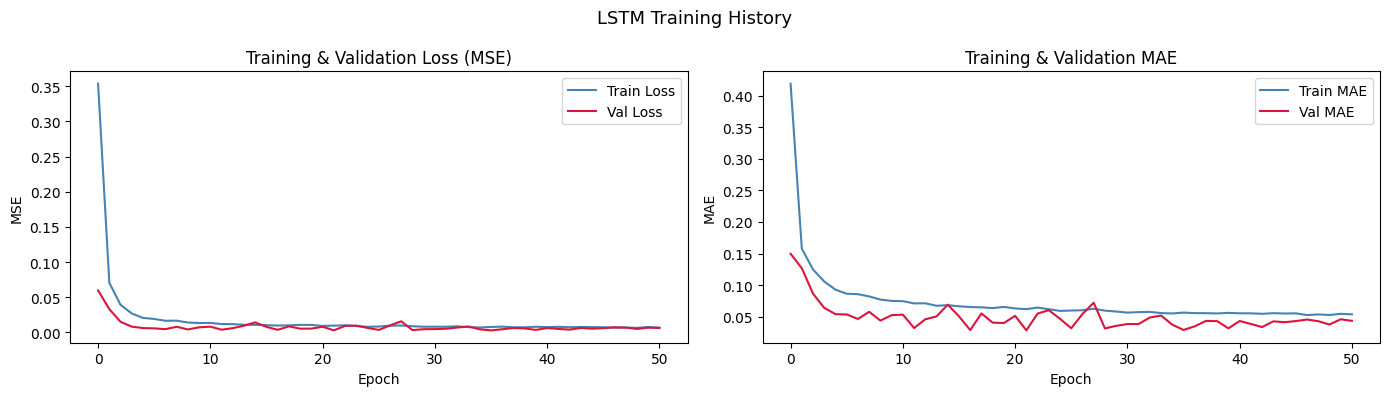

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='crimson')
axes[0].set_title('Training & Validation Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='crimson')
axes[1].set_title('Training & Validation MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=13)
plt.tight_layout()
plt.savefig(r'..\output\lstm_training_history.png', dpi=150)
plt.show()

## 7. Evaluate — MAE, RMSE, MAPE, MASE, DA

In [24]:
# Predict in scaled space, then inverse-transform back to original GDP scale
y_pred_test_s  = model.predict(X_test,  batch_size=512, verbose=0).flatten()
y_pred_val_s   = model.predict(X_val,   batch_size=512, verbose=0).flatten()
y_pred_train_s = model.predict(X_train, batch_size=512, verbose=0).flatten()

y_pred_test  = y_scaler.inverse_transform(y_pred_test_s.reshape(-1,  1)).flatten()
y_pred_val   = y_scaler.inverse_transform(y_pred_val_s.reshape(-1,   1)).flatten()
y_pred_train = y_scaler.inverse_transform(y_pred_train_s.reshape(-1, 1)).flatten()

# ── Metric helpers ───────────────────────────────────────────────────────────
def compute_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_da(y_true, y_pred, y_lag):
    actual_dir = np.sign(np.array(y_true) - np.array(y_lag))
    pred_dir   = np.sign(np.array(y_pred) - np.array(y_lag))
    return np.mean(actual_dir == pred_dir) * 100

# ── MASE: use same Naive MAE as Phases 4 & 5 for cross-model consistency ─────
metrics_so_far = pd.read_csv(os.path.join(OUTPUT, "model_metrics.csv"), index_col=0)
naive_mae = float(metrics_so_far.loc["Naive", "MAE"])
print(f"Naive MAE (from model_metrics.csv, test 2019-2024): {naive_mae:,.2f}")

# Lag GDP: GDP at anchor year t (to compute directional accuracy)
lag_map = model_df.set_index(["country_code", "year"])["gdp_per_capita"].to_dict()
val_meta["lag_gdp"] = [
    lag_map.get((val_meta.loc[i, "country_code"], val_meta.loc[i, "year"]), np.nan)
    for i in range(len(val_meta))
]
test_meta["lag_gdp"] = [
    lag_map.get((test_meta.loc[i, "country_code"], test_meta.loc[i, "year"]), np.nan)
    for i in range(len(test_meta))
]
valid_val_da = val_meta["lag_gdp"].notna().values
valid_da = test_meta["lag_gdp"].notna().values

lstm_val_metrics = {
    "MAE":  mean_absolute_error(y_val, y_pred_val),
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_val)),
    "MAPE": compute_mape(y_val, y_pred_val),
    "MASE": mean_absolute_error(y_val, y_pred_val) / naive_mae,
    "DA":   compute_da(y_val[valid_val_da], y_pred_val[valid_val_da],
                       val_meta.loc[valid_val_da, "lag_gdp"].values),
}

lstm_metrics = {
    "MAE":  mean_absolute_error(y_test, y_pred_test),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "MAPE": compute_mape(y_test, y_pred_test),
    "MASE": mean_absolute_error(y_test, y_pred_test) / naive_mae,
    "DA":   compute_da(y_test[valid_da], y_pred_test[valid_da],
                       test_meta.loc[valid_da, "lag_gdp"].values),
}

print("\n--- LSTM Validation Metrics ---")
for k, v in lstm_val_metrics.items():
    unit = "%" if k in ("MAPE", "DA") else ""
    print(f"  {k}: {v:.2f}{unit}")

print("\n--- LSTM Final Test Metrics ---")
for k, v in lstm_metrics.items():
    unit = "%" if k in ("MAPE", "DA") else ""
    print(f"  {k}: {v:.2f}{unit}")

print("\n--- LSTM Train Metrics ---")
print(f"  MAE: {mean_absolute_error(y_train, y_pred_train):,.2f}")

Naive MAE (from model_metrics.csv, test 2019-2024): 1,259.16

--- LSTM Validation Metrics ---
  MAE: 683.00
  RMSE: 1299.64
  MAPE: 4.70%
  MASE: 0.54
  DA: 68.30%

--- LSTM Final Test Metrics ---
  MAE: 1343.69
  RMSE: 3185.26
  MAPE: 8.75%
  MASE: 1.07
  DA: 63.71%

--- LSTM Train Metrics ---
  MAE: 721.75


## 8. Predicted vs Actual & Residuals

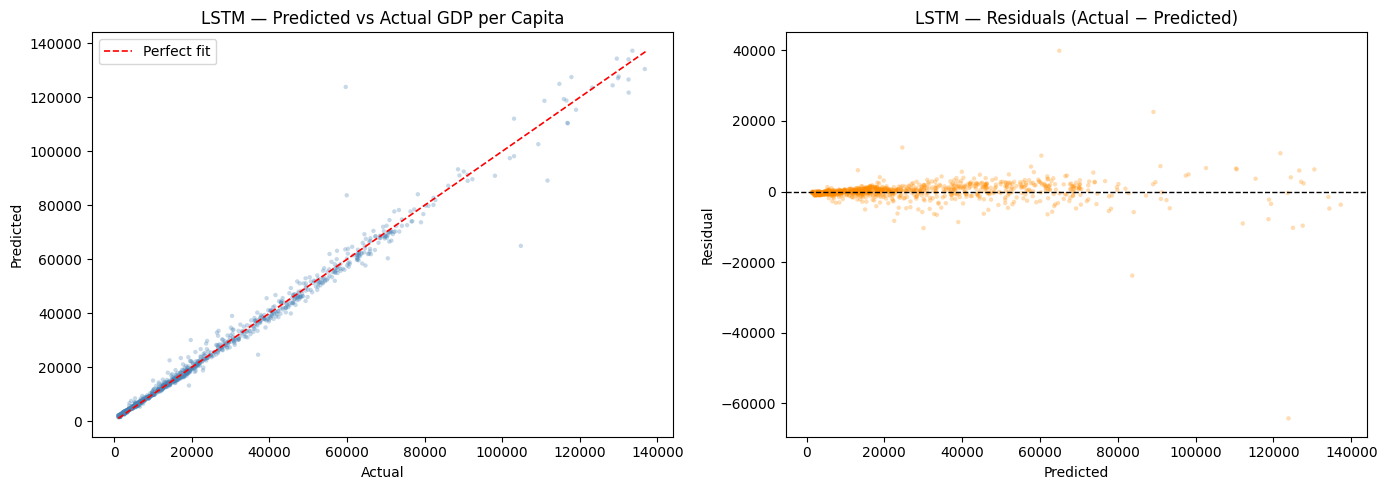

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue', edgecolors='none')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
ax.set_title('LSTM — Predicted vs Actual GDP per Capita')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.legend()

ax = axes[1]
residuals = y_test - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.3, s=10, color='darkorange', edgecolors='none')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('LSTM — Residuals (Actual − Predicted)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')

plt.tight_layout()
plt.savefig(r'..\output\lstm_predicted_vs_actual.png', dpi=150)
plt.show()

## 9. Country Trajectory Plots — Selected Economies

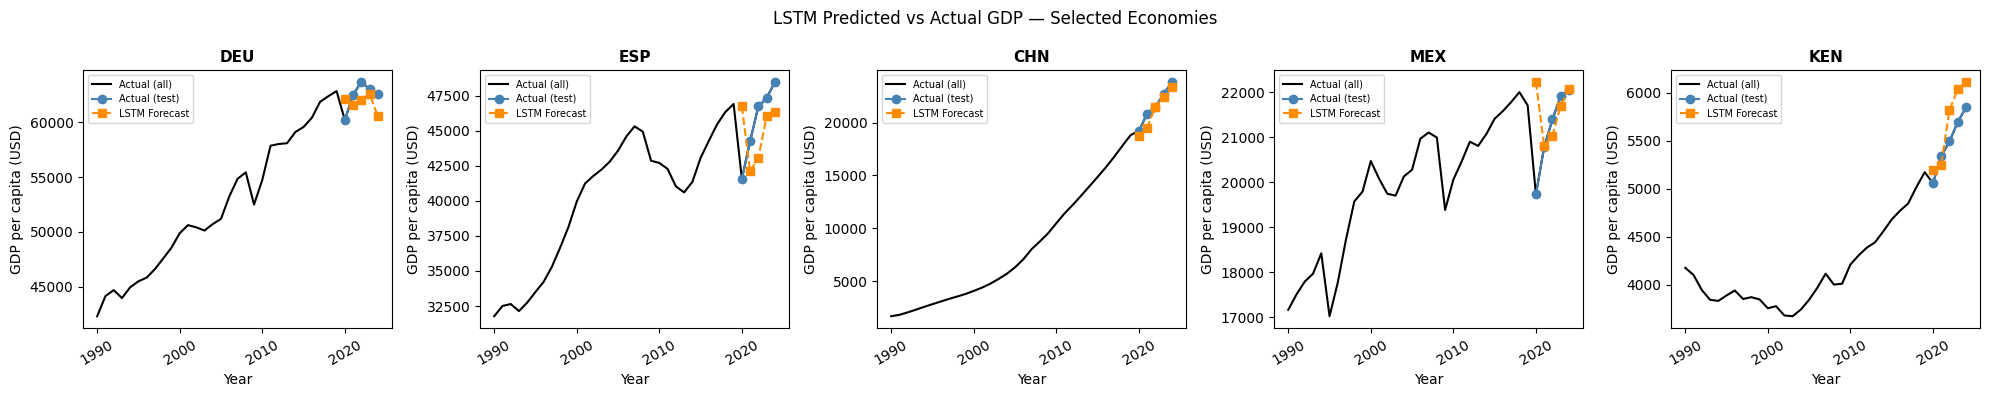

In [26]:
# Attach predictions to metadata
test_meta["actual"]    = y_test
test_meta["lstm_pred"] = y_pred_test
test_meta["pred_year"] = test_meta["year"] + 1   # anchor t -> actual GDP year t+1

# ── Plot selected country trajectories ───────────────────────────────────────
# Selected 5 countries representing different recovery profiles:
# Germany: developed fast recovery | Spain: developed slow recovery
# China: emerging super-fast | Mexico: emerging slower | Kenya: low-income
plot_countries = ["DEU", "ESP", "CHN", "MEX", "KEN"]
available = [c for c in plot_countries if c in test_meta["country_code"].values]

fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 4), sharey=False)
if len(available) == 1:
    axes = [axes]

for ax, country in zip(axes, available):
    hist = df[df["country_code"] == country].sort_values("year")
    pred = test_meta[test_meta["country_code"] == country].sort_values("pred_year")

    ax.plot(hist["year"], hist["gdp_per_capita"],
            color="black", linewidth=1.5, label="Actual (all)")
    ax.plot(pred["pred_year"], pred["actual"],
            "o-", color="steelblue", linewidth=1.5, label="Actual (test)")
    ax.plot(pred["pred_year"], pred["lstm_pred"],
            "s--", color="darkorange", linewidth=1.5, label="LSTM Forecast")
    ax.set_title(country, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("GDP per capita (USD)")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("LSTM Predicted vs Actual GDP — Selected Economies", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "lstm_country_forecasts.png"), dpi=150)
plt.show()

## 10. All Models Comparison — XGBoost vs ARIMA vs Holt ES vs LSTM

In [27]:
try:
    existing_metrics = pd.read_csv(r'..\output\model_metrics.csv', index_col=0)
    existing_metrics = existing_metrics.drop(index='Prophet', errors='ignore')
    print('Loaded existing metrics:')
    print(existing_metrics.round(4))
except FileNotFoundError:
    existing_metrics = pd.DataFrame()
    print('model_metrics.csv not found — run Phase 4 and Phase 5 first')


Loaded existing metrics:
               MAE       RMSE    MAPE   MASE      DA
Naive    1259.1600  3651.3900  4.8074 1.0000  0.0000
HistMean 6348.0000 10167.3600 25.6551 5.0415 34.6375
XGBoost  1254.2252  3602.8139  4.8556 0.9961 59.2635
ARIMA    1945.0129  5883.8395  7.6090 1.5447 59.8094



=== Model Comparison (Test Set 2020-2024) ===
               MAE       RMSE    MAPE   MASE      DA
Naive    1259.1600  3651.3900  4.8074 1.0000  0.0000
HistMean 6348.0000 10167.3600 25.6551 5.0415 34.6375
XGBoost  1254.2252  3602.8139  4.8556 0.9961 59.2635
ARIMA    1945.0129  5883.8395  7.6090 1.5447 59.8094
LSTM     1343.6880  3185.2578  8.7528 1.0671 63.7058


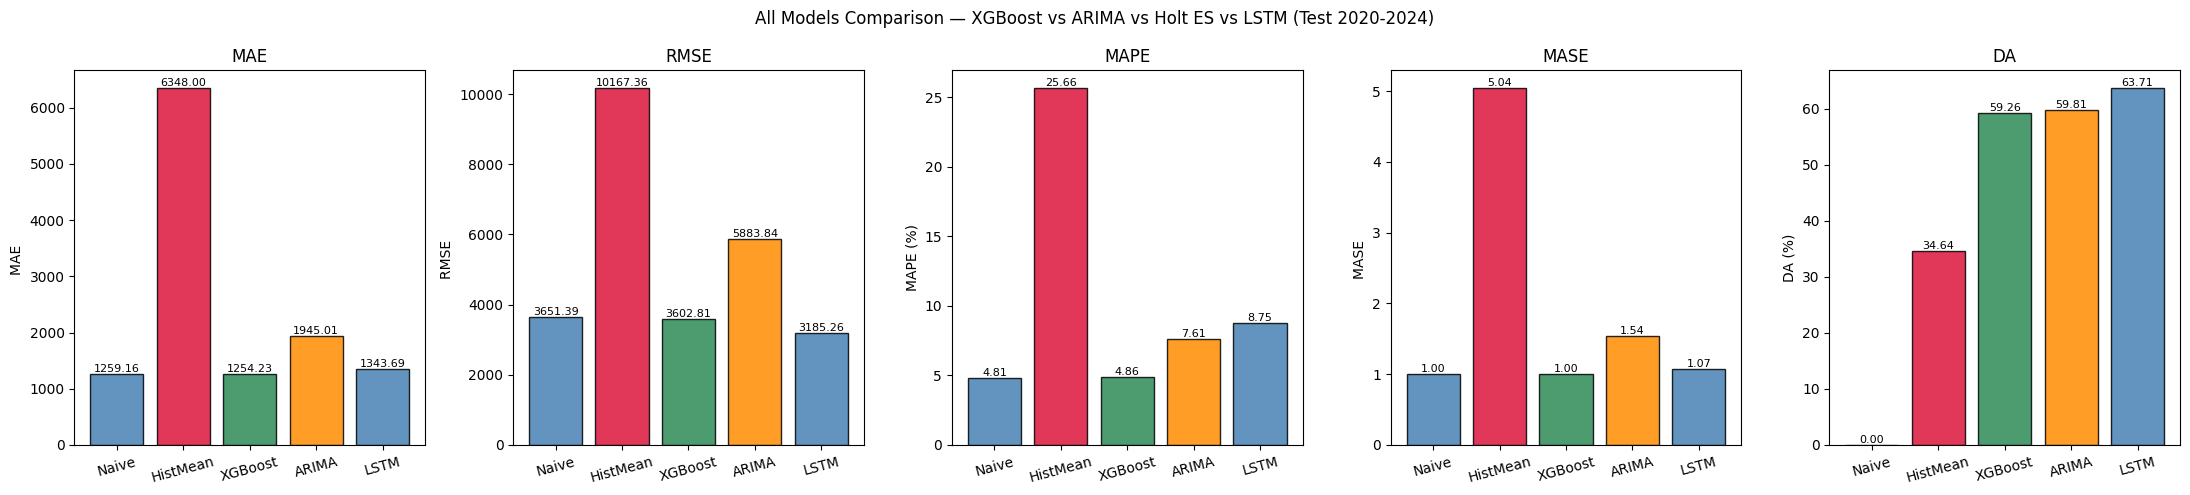

In [28]:
metrics_list = ['MAE', 'RMSE', 'MAPE', 'MASE', 'DA']
colors  = ['steelblue', 'crimson', 'seagreen', 'darkorange']

# Build comparison table — overwrite LSTM row if it already exists, then dedup
lstm_row = pd.DataFrame([lstm_metrics], index=['LSTM'])
lstm_row.index.name = existing_metrics.index.name
comparison = pd.concat([existing_metrics, lstm_row])
comparison = comparison[~comparison.index.duplicated(keep='last')]   # drop duplicate rows

print('\n=== Model Comparison (Test Set 2020-2024) ===')
print(comparison.round(4))

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
model_labels = comparison.index.tolist()
bar_colors   = colors[:len(model_labels)]

for ax, metric in zip(axes, metrics_list):
    vals = [float(comparison.at[m, metric]) if m in comparison.index else 0.0
            for m in model_labels]
    bars = ax.bar(model_labels, vals, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(f'{metric} {"(%)" if metric in ("MAPE", "DA") else ""}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('All Models Comparison — XGBoost vs ARIMA vs Holt ES vs LSTM (Test 2020-2024)', fontsize=12)
plt.tight_layout()
plt.savefig(r'..\output\phase6_model_comparison.png', dpi=150)
plt.show()

## 11. Recovery Speed Analysis — COVID-19 Shock

Recovery speed summary (years after 2020 to recover to pre-2020 GDP):
count   182.0000
mean      0.7967
std       1.1787
min       0.0000
25%       0.0000
50%       0.0000
75%       2.0000
max       4.0000
Name: lstm_recovery_years, dtype: float64
Recovered    : 182
Not recovered: 30


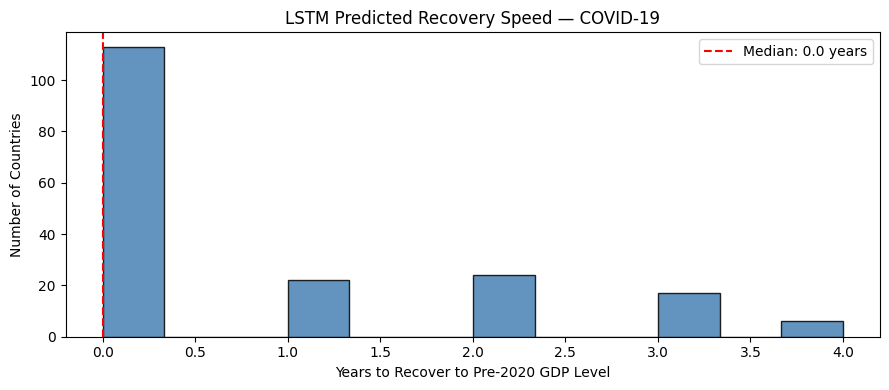

In [29]:
def compute_recovery_speed(meta_df, pred_col, df_orig, pre_shock_year=2019):
    """Years after 2020 for each country to reach pre-shock GDP per LSTM prediction."""
    records = []
    for country, grp in meta_df.groupby('country_code'):
        grp = grp.sort_values('pred_year')
        pre_row = df_orig[
            (df_orig['country_code'] == country) & (df_orig['year'] == pre_shock_year)
        ]['gdp_per_capita']
        if pre_row.empty:
            continue
        pre_gdp   = pre_row.values[0]
        recovered = grp[grp[pred_col] >= pre_gdp]
        speed     = int(recovered['pred_year'].min()) - 2020 if not recovered.empty else np.nan
        records.append({'country_code': country, 'lstm_recovery_years': speed})
    return pd.DataFrame(records)

lstm_recovery = compute_recovery_speed(test_meta, 'lstm_pred', df)
print('Recovery speed summary (years after 2020 to recover to pre-2020 GDP):')
print(lstm_recovery['lstm_recovery_years'].describe())
print(f'Recovered    : {lstm_recovery["lstm_recovery_years"].notna().sum()}')
print(f'Not recovered: {lstm_recovery["lstm_recovery_years"].isna().sum()}')

fig, ax = plt.subplots(figsize=(9, 4))
data = lstm_recovery['lstm_recovery_years'].dropna()
ax.hist(data, bins=12, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {data.median():.1f} years')
ax.set_title('LSTM Predicted Recovery Speed — COVID-19')
ax.set_xlabel('Years to Recover to Pre-2020 GDP Level')
ax.set_ylabel('Number of Countries')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\output\lstm_recovery_distribution.png', dpi=150)
plt.show()

## 12. Save Results

In [30]:
# ── Save LSTM predictions (standardized format: country_code|year|actual|predicted) ─
# year = pred_year (actual GDP year being predicted = anchor + 1)
lstm_out = test_meta[["country_code", "pred_year", "actual", "lstm_pred"]].copy()
lstm_out.columns = ["country_code", "year", "actual", "predicted"]
lstm_out.to_csv(os.path.join(OUTPUT, "lstm_test_predictions.csv"), index=False)

# Recovery CSV
lstm_recovery.to_csv(os.path.join(OUTPUT, "lstm_recovery_speed.csv"), index=False)

# ── Append LSTM row to model_metrics.csv ─────────────────────────────────────
existing = pd.read_csv(os.path.join(OUTPUT, "model_metrics.csv"), index_col=0)

new_row = pd.DataFrame(
    [{k: round(v, 4) for k, v in lstm_metrics.items()}],
    index=["LSTM"]
)
new_row.columns = existing.columns

# Overwrite LSTM row if already present, otherwise append
if "LSTM" in existing.index:
    existing.loc["LSTM"] = new_row.loc["LSTM"]
    all_metrics = existing
else:
    all_metrics = pd.concat([existing, new_row])

all_metrics.to_csv(os.path.join(OUTPUT, "model_metrics.csv"))

print("Saved:")
print("  lstm_test_predictions.csv  (format: country_code, year, actual, predicted)")
print("  lstm_recovery_speed.csv")
print("  model_metrics.csv (updated with LSTM)")
print()
print("=== Final All-Model Metrics ===")
print(all_metrics.round(4))

Saved:
  lstm_test_predictions.csv  (format: country_code, year, actual, predicted)
  lstm_recovery_speed.csv
  model_metrics.csv (updated with LSTM)

=== Final All-Model Metrics ===
               MAE       RMSE    MAPE   MASE      DA
Naive    1259.1600  3651.3900  4.8074 1.0000  0.0000
HistMean 6348.0000 10167.3600 25.6551 5.0415 34.6375
XGBoost  1254.2252  3602.8139  4.8556 0.9961 59.2635
ARIMA    1945.0129  5883.8395  7.6090 1.5447 59.8094
LSTM     1343.6880  3185.2578  8.7528 1.0671 63.7058


In [31]:
lstm_val_out = val_meta.copy()

lstm_val_out["actual"] = y_val
lstm_val_out["predicted"] = y_pred_val

lstm_val_out["pred_year"] = lstm_val_out["year"] + 1

lstm_val_out[
    ["country_code","pred_year","actual","predicted"]
].rename(
    columns={"pred_year":"year"}
).to_csv(
    os.path.join(OUTPUT,"lstm_validation_predictions.csv"),
    index=False
)

---
## Phase 6 Complete

**Model architecture:**
- Input: 5-year sliding window × 24 features
- LSTM(128, return_sequences=True) → Dropout(0.2)
- LSTM(64) → Dropout(0.2)
- Dense(32, relu) → Dense(1)
- Optimizer: Adam(lr=0.001), EarlyStopping(patience=15)

**Outputs saved:**
- `output/lstm_test_predictions.csv`
- `output/lstm_recovery_speed.csv`
- `output/model_metrics.csv` (extended with LSTM row)
- `output/lstm_training_history.png`
- `output/lstm_predicted_vs_actual.png`
- `output/lstm_country_forecasts.png`
- `output/lstm_recovery_distribution.png`
- `output/phase6_model_comparison.png`

**Next → Phase 7:** Final comparison report & recovery analysis